# 05 · Approach 3: Pretrained transformer (XLM-R / AfroXLMR / AfriBERTa) fine-tuning
 Runtime: Colab **GPU** (T4). Total for all experiments: about 1–1.5 h.

**Why this model.** Self-attention relates every token to every other token in one step, so
dependencies between distant parts of the article are modelled directly instead of being passed
along a recurrent chain (Vaswani et al., 2017). Pretraining gives the model knowledge of Swahili that
3,600 training articles cannot provide. We compare a general multilingual model, **XLM-R**
(Conneau et al., 2020), with **AfroXLMR**, the same model further adapted to 17 African languages
including Swahili (Alabi et al., 2022), and **AfriBERTa**, a smaller model pretrained only on African
languages (Ogueji et al., 2021). On MasakhaNEWS, a news-topic benchmark for 16 African languages
including Swahili, fine-tuned African-centric models of this kind are among the strongest baselines
(Adelani et al., 2023).
**Limitations:** 512 sub-word tokens is a hard limit, and articles are long; 100–280M parameters vs
~5M for the CNN; slow inference.

## 0 · Setup
Run this cell first. On **Google Colab** it clones the repo, installs requirements and copies the
data from your Google Drive. Locally it does nothing special.

**Before the first run:** put `Train.csv`, `Test.csv` and `SampleSubmission.csv` (from Zindi) in a
Google Drive folder called `swahili_news`, and set `REPO_URL` below.

In [2]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_URL = "https://github.com/N-SilverJr/swahili-news-sequential.git"
    REPO_DIR = Path("/content/swahili-news-sequential")
    DRIVE_DATA = Path("/content/drive/MyDrive/swahili-news")
    LOCAL_DATA = Path("/content/data")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if not (LOCAL_DATA / ".ready").exists():
        LOCAL_DATA.mkdir(parents=True, exist_ok=True)
        for f in DRIVE_DATA.glob("*.csv"):
            shutil.copy(f, LOCAL_DATA)
        (LOCAL_DATA / ".ready").touch()
    os.environ["DATA_DIR"] = str(LOCAL_DATA)
    os.environ["CACHE_DIR"] = str(DRIVE_DATA / "cache")
    os.environ["OUTPUT_BACKUP_DIR"] = str(DRIVE_DATA / "outputs")
else:
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/swahili-news-sequential


In [3]:
import os
from functools import partial

import numpy as np
import torch

from src import config as C
from src.data import get_splits, split_frames, encode_labels, load_unlabelled
from src.datasets import TransformerDataset, transformer_collate
from src.models import HFTextClassifier
from src.pipeline import run_experiments, finalize
from src.text import GLUED, head_tail, tokenize, Vocab
from src.utils import set_seed, get_device

MEMBER, MODEL = "Berissa Muyizere", "Transformer"
TINY = os.environ.get("TINY_TRANSFORMER") == "1"
set_seed(C.SEED)
print("Device:", get_device())
df = get_splits()
tr, va, te = split_frames(df)
ytr, yva, yte = (encode_labels(d.label) for d in (tr, va, te))
zindi = load_unlabelled()
K = len(C.CLASSES)

Device: cuda
Split sizes: {'train': 3605, 'test': 773, 'val': 773}


## Sub-word tokenisation with head / head+tail truncation
Only the glued-sentence repair is applied: the pretrained tokenisers expect natural, cased text.
Head+tail keeps the first and the last part of a long article. Sun et al. (2019) found that keeping
the head and the tail beats head-only truncation for long-document classification with BERT.

In [4]:
class _TinyTokenizer:
    pad_token_id = 1

    def __init__(self):
        self.v = Vocab(tr.content.map(tokenize))

    def __call__(self, text, add_special_tokens=False):
        return {"input_ids": [i + 4 for i in self.v.encode(tokenize(text))]}

    def build_inputs_with_special_tokens(self, ids):
        return [0] + ids + [2]


_tok, _enc = {}, {}


def tokenizer(ckpt):
    if ckpt not in _tok:
        if TINY:
            _tok[ckpt] = _TinyTokenizer()
        else:
            from transformers import AutoTokenizer
            _tok[ckpt] = AutoTokenizer.from_pretrained(ckpt)
    return _tok[ckpt]


def encode(ckpt, head_frac=1.0):
    key = (ckpt, head_frac)
    if key not in _enc:
        tk = tokenizer(ckpt)
        body = C.MAX_TOKENS - 2
        def one(t):
            ids = tk(GLUED.sub(r"\1 ", t), add_special_tokens=False)["input_ids"]
            return tk.build_inputs_with_special_tokens(head_tail(ids, body, head_frac))
        _enc[key] = {n: {"input_ids": [one(t) for t in d.content]} for n, d in
                     {"tr": tr, "va": va, "te": te, "z": zindi}.items()}
        lens = np.array([len(tk(GLUED.sub(r"\1 ", t))["input_ids"]) for t in tr.content])
        print(f"{ckpt}: median {np.median(lens):.0f} sub-word tokens; {(lens > C.MAX_TOKENS).mean():.1%} of "
              f"training articles are longer than {C.MAX_TOKENS} and get truncated")
    return _enc[key]


def collate_for(ckpt):
    return partial(transformer_collate, pad_id=tokenizer(ckpt).pad_token_id)


def make_datasets(p):
    e = encode(p["checkpoint"], p.get("head_frac", 1.0))
    return TransformerDataset(e["tr"], ytr), TransformerDataset(e["va"], yva)


def build_model(p):
    return HFTextClassifier(p["checkpoint"], K, tiny_random=TINY,
                            vocab_size=len(tokenizer(p["checkpoint"]).v) + 4 if TINY else None)

In [5]:
!pip install -U "transformers>=4.44,<5.0" "tokenizers>=0.19,<0.22"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 

## Experiments
Effective batch 32 (16 × 2 gradient accumulation), learning rate 3e-5 with warm-up (one-cycle),
early stopping on validation log loss.

In [5]:
XLMR, AFROXLMR, AFRIBERTA = "FacebookAI/xlm-roberta-base", "Davlan/afro-xlmr-base", "castorini/afriberta_base"
HEAD_TAIL = 128 / 510
DEFAULT_TRAIN = dict(epochs=5, lr=3e-5, batch_size=16, grad_accum=2, weight_decay=0.01, patience=2, num_workers=2)
EXPERIMENTS = [
    dict(id="TR-01", description="XLM-R base (100 languages), head 512 tokens",
         hypothesis="Multilingual pretraining plus self-attention beats models trained from scratch.",
         motivated_by="Starting point (compare with best CNN/RNN)", params={"checkpoint": XLMR}),
    dict(id="TR-02", description="AfroXLMR base (XLM-R adapted to African languages), head 512",
         hypothesis="Further pretraining on African-language text (incl. Swahili) improves Swahili news classification.",
         motivated_by="TR-01 + Alabi et al. (2022), Adelani et al. (2023)", params={"checkpoint": AFROXLMR}),
    dict(id="TR-03", description="AfroXLMR, head+tail truncation (128 + 382 tokens)",
         hypothesis="For articles longer than 512 tokens, the ending holds information the head misses.",
         motivated_by="EDA 4: many articles exceed 512 sub-words; EDA 8 keyword position; Sun et al. (2019)",
         params={"checkpoint": AFROXLMR, "head_frac": HEAD_TAIL}),
    dict(id="TR-04", description="AfroXLMR + class-weighted loss (best truncation)",
         hypothesis="Weighting helps the 11 burudani / 38 kimataifa training articles.",
         motivated_by="EDA 2 + per-class F1 of TR-02/03",
         params={"checkpoint": AFROXLMR, "head_frac": HEAD_TAIL}, train={"class_weights": True}),
    dict(id="TR-05", description="AfriBERTa base (pretrained only on African languages, smaller)",
         hypothesis="A smaller, African-only model is competitive at a fraction of the cost.",
         motivated_by="Cost/benefit question after TR-02", params={"checkpoint": AFRIBERTA}),
]

if TINY:
    for e in EXPERIMENTS:
        e.setdefault("train", {}).update(batch_size=8, grad_accum=1, lr=1e-3, num_workers=0)

best, rows = None, []
for e in EXPERIMENTS:
    b, s = run_experiments([e], build_model, make_datasets, member=MEMBER, model_name=MODEL, n_classes=K,
                           y_train=ytr, default_train=DEFAULT_TRAIN, collate_fn=collate_for(e["params"]["checkpoint"]))
    rows.append(s)
    if best is None or b["metrics"]["log_loss"] < best["metrics"]["log_loss"]:
        best = b
    else:
        del b
import pandas as pd
summary = pd.concat(rows, ignore_index=True)
print("Best on validation:", best["exp"]["id"])
summary.round(4)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (582 > 512). Running this sequence through the model will result in indexing errors



===== TR-01: XLM-R base (100 languages), head 512 tokens =====
FacebookAI/xlm-roberta-base: median 428 sub-word tokens; 34.5% of training articles are longer than 512 and get truncated


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ep   1 | train loss 0.8315 acc 0.656 | val loss 0.3877 acc 0.847 F1 0.511 | 99s
ep   2 | train loss 0.3925 acc 0.868 | val loss 0.3214 acc 0.881 F1 0.530 | 105s
ep   3 | train loss 0.2982 acc 0.901 | val loss 0.2747 acc 0.904 F1 0.544 | 106s
ep   4 | train loss 0.2261 acc 0.926 | val loss 0.2765 acc 0.906 F1 0.546 | 106s
ep   5 | train loss 0.1854 acc 0.942 | val loss 0.2808 acc 0.904 F1 0.545 | 106s
Early stopping at epoch 5 (best val log loss 0.2747)


...

pytorch_model.bin:   0%|          | 0.00/446M [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at castorini/afriberta_base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/446M [00:00<?, ?B/s]

ep   1 | train loss 0.6948 acc 0.728 | val loss 0.3680 acc 0.845 F1 0.509 | 65s
ep   2 | train loss 0.3046 acc 0.889 | val loss 0.2712 acc 0.893 F1 0.736 | 64s
ep   3 | train loss 0.2067 acc 0.930 | val loss 0.2918 acc 0.900 F1 0.730 | 64s
ep   4 | train loss 0.1336 acc 0.961 | val loss 0.3025 acc 0.916 F1 0.724 | 64s
Early stopping at epoch 4 (best val log loss 0.2712)
--> TR-05 val log loss 0.2712 | acc 0.893 | macro-F1 0.736 | 4.3 min

Best configuration on validation: TR-05 (AfriBERTa base (pretrained only on African languages, smaller))
Best on validation: TR-04


,exp_id,description,val_log_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top2_accuracy,val_ece,val_roc_auc_ovr_macro,best_epoch,epochs_run,train_gap_acc,params,minutes
0,TR-01,"XLM-R base (100 languages), head 512 tokens",0.2747,0.9043,0.5438,0.8964,0.9884,0.0172,0.9680,3,5,0.0380,278047493,8.7860
1,TR-02,AfroXLMR base (XLM-R adapted to African langua...,0.2165,0.9237,0.6006,0.9181,0.9935,0.0178,0.9889,3,5,0.0424,278047493,8.9143
2,TR-03,"AfroXLMR, head+tail truncation (128 + 382 tokens)",0.2258,0.9069,0.5897,0.9011,0.9922,0.0287,0.9861,3,5,0.0587,278047493,8.9437
3,TR-04,AfroXLMR + class-weighted loss (best truncation),0.2073,0.9107,0.8201,0.9114,0.9974,0.0313,0.9898,4,5,0.0431,278047493,8.9264
4,TR-05,AfriBERTa base (pretrained only on African lan...,0.2712,0.8926,0.7356,0.8909,0.9961,0.0178,0.9842,2,4,0.0455,111459077,4.2965


> Fill the `observation` column in `experiments/log_transformer.csv`: XLM-R vs AfroXLMR vs AfriBERTa
> (does African-language pretraining matter?), head vs head+tail, class weights. Note the training
> time and parameter count too: that is the cost side of the trade-off.

## Final evaluation on the test split (once)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at Davlan/afro-xlmr-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

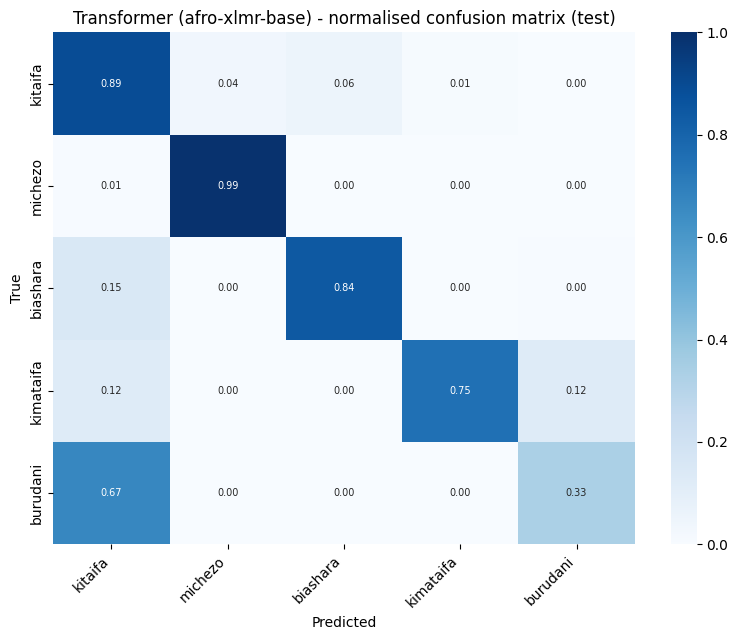

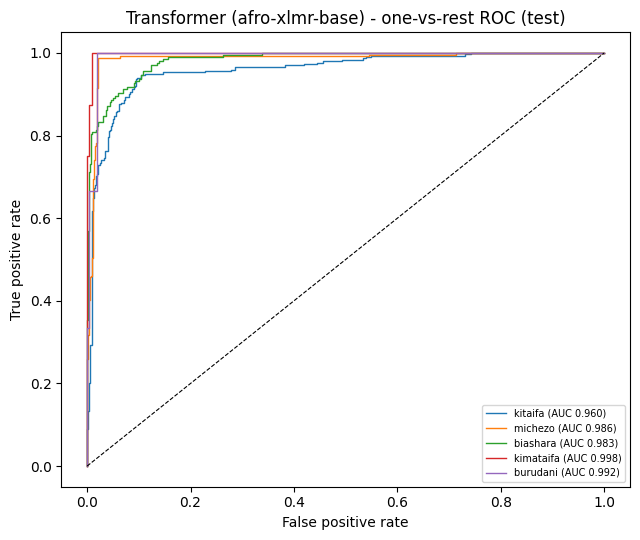

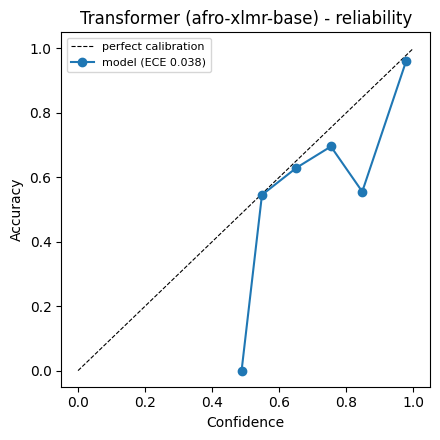

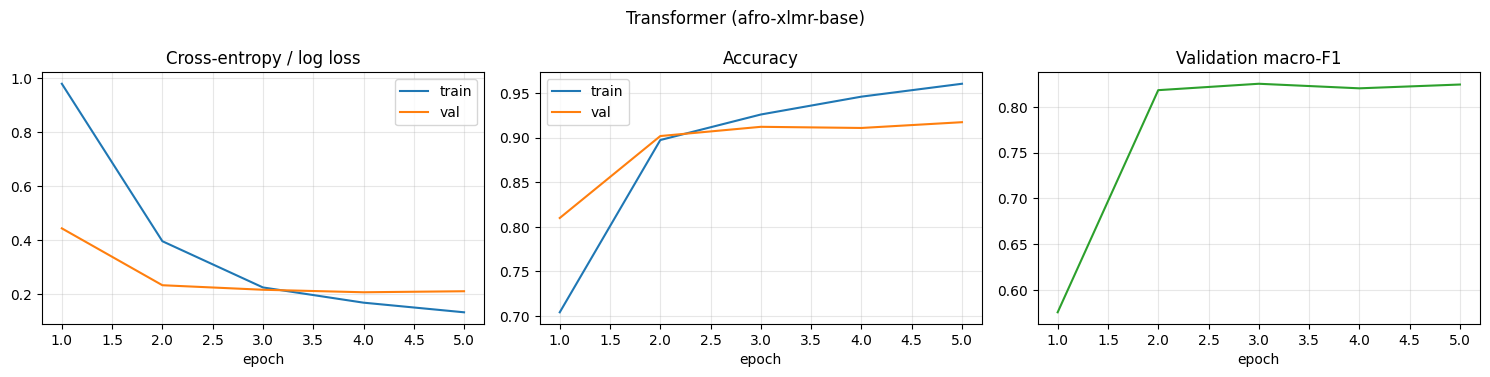

{
  "log_loss": 0.2748,
  "accuracy": 0.9082,
  "macro_f1": 0.7451,
  "weighted_f1": 0.9081,
  "top2_accuracy": 0.9922,
  "ece": 0.0379,
  "roc_auc_ovr_macro": 0.9838,
  "log_loss_ci95": [
    0.21752504164869407,
    0.3383925487086462
  ],
  "accuracy_ci95": [
    0.88745148771022,
    0.9288486416558862
  ],
  "macro_f1_ci95": [
    0.6448872828475242,
    0.8401472241115552
  ],
  "model": "Transformer (afro-xlmr-base)",
  "key": "transformer",
  "selected_experiment": "TR-04",
  "n_trainable_params": 278047493,
  "val_log_loss": 0.2073
}
Submission written to /content/swahili-news-sequential/submissions/transformer.csv


In [6]:
p = best["exp"]["params"]
enc = encode(p["checkpoint"], p.get("head_frac", 1.0))
model, proba_test, metrics = finalize(best, build_model, TransformerDataset(enc["te"], yte), yte, te.id.values,
                                      C.CLASSES, key="transformer", display_name=f"Transformer ({p['checkpoint'].split('/')[-1]})",
                                      collate_fn=collate_for(p["checkpoint"]), save_weights=False,
                                      zindi_ds=TransformerDataset(enc["z"]), zindi_df=zindi)

In [7]:
from src.utils import persist_outputs
persist_outputs()

Outputs copied to /content/drive/MyDrive/swahili-news/outputs


In [8]:
!cd /content/swahili-news-sequential && git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	experiments/log_transformer.csv
	results/transformer/
	submissions/transformer.csv

nothing added to commit but untracked files present (use "git add" to track)


In [9]:
!git -C /content/swahili-news-sequential config user.name "Muyizereberissa"
!git -C /content/swahili-news-sequential config user.email "b.muyizere@alustudent.com"

In [10]:
!cd /content/swahili-news-sequential && git add notebooks/05_transformer.ipynb submissions/ results/ experiments/
!cd /content/swahili-news-sequential && git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   experiments/log_transformer.csv
	new file:   results/transformer/confusion.png
	new file:   results/transformer/history.csv
	new file:   results/transformer/learning_curves.png
	new file:   results/transformer/metrics.json
	new file:   results/transformer/per_class.csv
	new file:   results/transformer/predictions.csv
	new file:   results/transformer/reliability.png
	new file:   results/transformer/roc.png
	new file:   submissions/transformer.csv



In [11]:
!cd /content/swahili-news-sequential && git commit -m "Transformer complete: run notebook, add results and figures"

[main 9dd440e] Transformer complete: run notebook, add results and figures
 10 files changed, 2107 insertions(+)
 create mode 100644 experiments/log_transformer.csv
 create mode 100644 results/transformer/confusion.png
 create mode 100644 results/transformer/history.csv
 create mode 100644 results/transformer/learning_curves.png
 create mode 100644 results/transformer/metrics.json
 create mode 100644 results/transformer/per_class.csv
 create mode 100644 results/transformer/predictions.csv
 create mode 100644 results/transformer/reliability.png
 create mode 100644 results/transformer/roc.png
 create mode 100644 submissions/transformer.csv


In [ ]:
import getpass, subprocess

token = getpass.getpass("Paste PAT (input hidden): ")
url = f"https://{token}@github.com/N-SilverJr/swahili-news-sequential.git"

r = subprocess.run(
    ["git", "-C", "/content/swahili-news-sequential", "push", url, "main"],
    capture_output=True, text=True,
)

print("--- stdout ---")
print(r.stdout.replace(token, "***REDACTED***"))
print("--- stderr ---")
print(r.stderr.replace(token, "***REDACTED***"))
print("returncode:", r.returncode)

del token, url